# ForeForest neural leaf regression example

This notebook builds a synthetic nonlinear regression dataset and compares two scalar-output `ForeForest` models:

- standard GBDT trees
- GBDT trees with neural leaves enabled

The current branch is scalar-output only, so targets are 1-D and predictions return one value per row.

## Notes

- The notebook tries to import the built `foreforest` extension from `tree/build/` first.
- `tree_cfg.neural_cfg.enabled = True` is the Python-facing switch for neural leaves.
- The lower-level neural leaf hyperparameters are not broadly exposed in the current Python bindings, so this example uses the compiled defaults.

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
candidates = [
    ROOT / "build",
    ROOT.parent / "build",
    ROOT / "tree" / "build",
    ROOT.parent / "tree" / "build",
]

for cand in reversed([p for p in candidates if p.exists()]):
    sys.path.insert(0, str(cand))

import foreforest

print("foreforest:", foreforest.__file__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

foreforest: /data/back_home/baseline/foreblocks/tree/build/foreforest.cpython-312-x86_64-linux-gnu.so
numpy: 2.3.5
pandas: 2.3.3


In [2]:
def mse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float(np.mean((y_true - y_pred) ** 2))


def make_synthetic_regression(n=5000, p=8, seed=7):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, p)).astype(np.float64)

    signal = (
        1.8 * np.sin(1.7 * X[:, 0])
        + 0.8 * X[:, 1] * X[:, 2]
        - 0.6 * np.cos(X[:, 3] * X[:, 4])
        + 0.35 * (X[:, 5] ** 2)
        - 0.25 * (X[:, 6] ** 3)
    )
    local_regime = np.where(X[:, 0] + X[:, 1] > 0.75, 1.2 * np.tanh(2.0 * X[:, 7]), -0.8 * X[:, 7])
    noise = rng.normal(0.0, 0.12 + 0.08 * np.abs(X[:, 0]), size=n)
    y = (signal + local_regime + noise).astype(np.float64)
    return X, y


def split_train_valid_test(X, y, train_ratio=0.7, valid_ratio=0.15, seed=11):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(X.shape[0])
    n_train = int(train_ratio * len(idx))
    n_valid = int(valid_ratio * len(idx))

    i_train = idx[:n_train]
    i_valid = idx[n_train:n_train + n_valid]
    i_test = idx[n_train + n_valid:]

    return (
        X[i_train], y[i_train],
        X[i_valid], y[i_valid],
        X[i_test], y[i_test],
    )


X, y = make_synthetic_regression()
X_train, y_train, X_valid, y_valid, X_test, y_test = split_train_valid_test(X, y)

print("train:", X_train.shape, y_train.shape)
print("valid:", X_valid.shape, y_valid.shape)
print("test :", X_test.shape, y_test.shape)

train: (3500, 8) (3500,)
valid: (750, 8) (750,)
test : (750, 8) (750,)


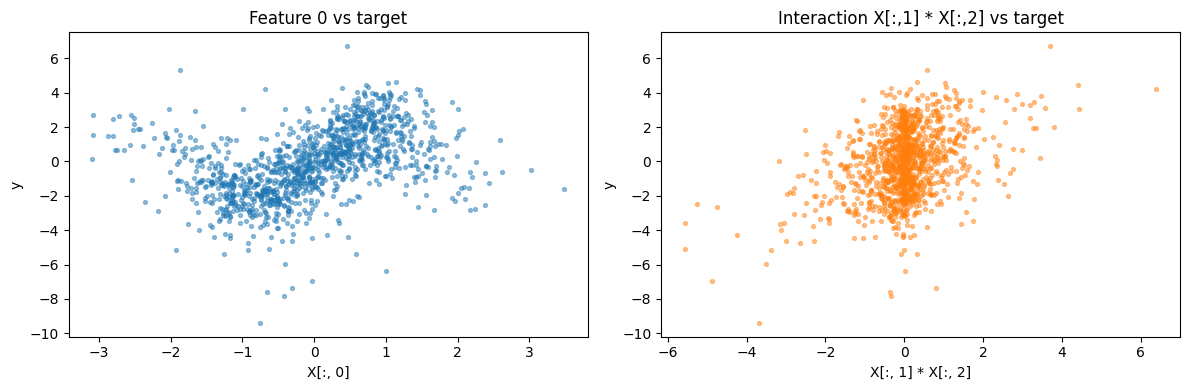

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(X_train[:1200, 0], y_train[:1200], s=8, alpha=0.45)
ax[0].set_title("Feature 0 vs target")
ax[0].set_xlabel("X[:, 0]")
ax[0].set_ylabel("y")

ax[1].scatter(X_train[:1200, 1] * X_train[:1200, 2], y_train[:1200], s=8, alpha=0.45, color="tab:orange")
ax[1].set_title("Interaction X[:,1] * X[:,2] vs target")
ax[1].set_xlabel("X[:, 1] * X[:, 2]")
ax[1].set_ylabel("y")
plt.tight_layout()

In [4]:
def build_hist_cfg():
    hist_cfg = foreforest.HistogramConfig()
    hist_cfg.method = "adaptive"
    hist_cfg.max_bins = 256
    hist_cfg.use_missing_bin = True
    hist_cfg.adaptive_binning = True
    hist_cfg.use_parallel = False
    return hist_cfg


def build_tree_cfg(use_neural_leaf):
    tree_cfg = foreforest.TreeConfig()
    tree_cfg.max_depth = 6
    tree_cfg.max_leaves = 31
    tree_cfg.min_samples_split = 20
    tree_cfg.min_samples_leaf = 12
    tree_cfg.min_child_weight = 1e-3
    tree_cfg.lambda_ = 1.0
    tree_cfg.alpha_ = 0.0
    tree_cfg.gamma_ = 0.0
    tree_cfg.growth = foreforest.Growth.LeafWise
    tree_cfg.split_mode = foreforest.SplitMode.Histogram
    tree_cfg.enable_oblique_splits = False
    tree_cfg.enable_kway_splits = False
    tree_cfg.goss.enabled = False
    tree_cfg.neural_cfg.enabled = bool(use_neural_leaf)
    return tree_cfg


def build_forest_cfg(use_neural_leaf):
    cfg = foreforest.ForeForestConfig()
    cfg.mode = foreforest.Mode.GBDT
    cfg.objective = foreforest.Objective.SquaredError
    cfg.n_estimators = 120
    cfg.learning_rate = 0.08
    cfg.rng_seed = 123
    cfg.colsample_bytree = 0.9
    cfg.colsample_bynode = 0.9
    cfg.gbdt_use_subsample = True
    cfg.gbdt_row_subsample = 0.85
    cfg.early_stopping_enabled = True
    cfg.early_stopping_rounds = 15
    cfg.early_stopping_min_delta = 0.0
    cfg.dart_enabled = False
    cfg.hist_cfg = build_hist_cfg()
    cfg.tree_cfg = build_tree_cfg(use_neural_leaf)
    return cfg


def train_and_evaluate(use_neural_leaf):
    label = "GBDT + neural leaves" if use_neural_leaf else "GBDT baseline"
    cfg = build_forest_cfg(use_neural_leaf)
    model = foreforest.ForeForest(cfg)

    t0 = time.perf_counter()
    model.fit_complete(X_train, y_train, X_valid, y_valid)
    fit_s = time.perf_counter() - t0

    pred_valid = np.asarray(model.predict(X_valid), dtype=np.float64)
    pred_test = np.asarray(model.predict(X_test), dtype=np.float64)

    return {
        "label": label,
        "model": model,
        "pred_valid": pred_valid,
        "pred_test": pred_test,
        "fit_s": fit_s,
        "mse_valid": mse(y_valid, pred_valid),
        "mse_test": mse(y_test, pred_test),
        "trees": int(model.size()),
        "best_iteration": int(model.best_iteration()),
        "early_stopped": bool(model.early_stopped()),
    }

In [5]:
baseline = train_and_evaluate(use_neural_leaf=False)
neural_leaf = train_and_evaluate(use_neural_leaf=True)

results = pd.DataFrame([
    {
        "model": baseline["label"],
        "fit_s": baseline["fit_s"],
        "mse_valid": baseline["mse_valid"],
        "mse_test": baseline["mse_test"],
        "trees": baseline["trees"],
        "best_iteration": baseline["best_iteration"],
        "early_stopped": baseline["early_stopped"],
    },
    {
        "model": neural_leaf["label"],
        "fit_s": neural_leaf["fit_s"],
        "mse_valid": neural_leaf["mse_valid"],
        "mse_test": neural_leaf["mse_test"],
        "trees": neural_leaf["trees"],
        "best_iteration": neural_leaf["best_iteration"],
        "early_stopped": neural_leaf["early_stopped"],
    },
])

results

,model,fit_s,mse_valid,mse_test,trees,best_iteration,early_stopped
0,GBDT baseline,0.131313,0.677136,0.615493,120,120,False
1,GBDT + neural leaves,0.683085,0.677136,0.615493,120,120,False


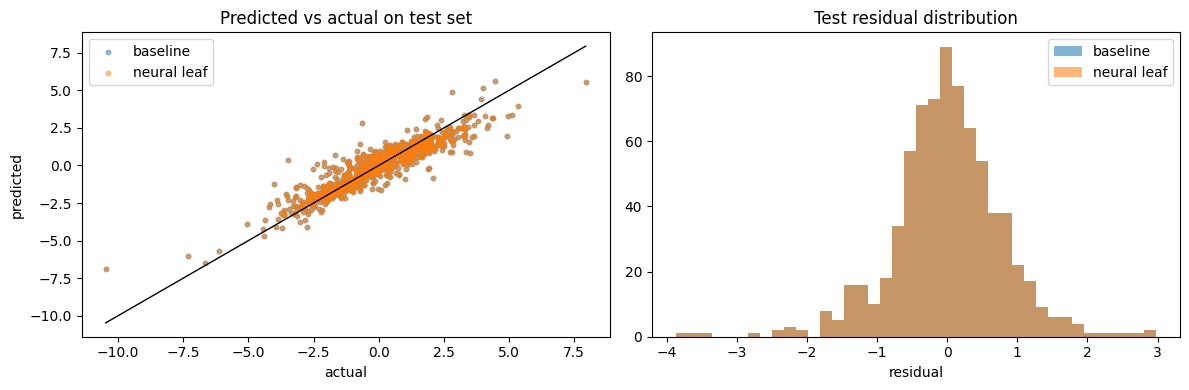

: 

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(y_test, baseline["pred_test"], s=10, alpha=0.45, label="baseline")
ax[0].scatter(y_test, neural_leaf["pred_test"], s=10, alpha=0.45, label="neural leaf")
mn = min(y_test.min(), baseline["pred_test"].min(), neural_leaf["pred_test"].min())
mx = max(y_test.max(), baseline["pred_test"].max(), neural_leaf["pred_test"].max())
ax[0].plot([mn, mx], [mn, mx], color="black", linewidth=1)
ax[0].set_title("Predicted vs actual on test set")
ax[0].set_xlabel("actual")
ax[0].set_ylabel("predicted")
ax[0].legend()

resid_baseline = y_test - baseline["pred_test"]
resid_neural = y_test - neural_leaf["pred_test"]
ax[1].hist(resid_baseline, bins=40, alpha=0.55, label="baseline")
ax[1].hist(resid_neural, bins=40, alpha=0.55, label="neural leaf")
ax[1].set_title("Test residual distribution")
ax[1].set_xlabel("residual")
ax[1].legend()

plt.tight_layout()

## Interpretation

If the neural-leaf model improves test MSE on this synthetic dataset, it suggests the leaf-level MLP is helping capture local nonlinear structure after the tree has partitioned the feature space.

If it does not improve, the usual reasons are:

- the tree partitions are already expressive enough
- the default neural leaf hyperparameters are not ideal for this dataset
- the leaves are too small for the neural model to add value consistently

That is expected in this branch because the Python API currently exposes only the neural-leaf enable/disable switch, not the full neural leaf tuning surface.